# Probability distributions and simulation

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/03-variability-and-inference.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

Engineers use probability distributions to describe quantities that vary: a manufacturing dimension, a load, a sensor reading, or an emission measurement. In this notebook, you will use NumPy to simulate and visualize a few common distributions.

This is preparation for our in-class discussion of the central limit theorem (CLT). We will discuss sampling distributions, formal hypothesis tests, and p-values together in class.

**Learning objectives**

- Draw random samples from normal, uniform, and exponential distributions with NumPy.
- Use histograms to compare the shapes of simulated distributions.
- Calculate and interpret a sample mean and standard deviation.
- Relate a distribution to both a familiar situation and a possible engineering application.
概率分布与模拟

在 Colab 中打开

工程师使用概率分布来描述变化的量：例如制造尺寸、负载、传感器读数或排放测量值。在本笔记本中，您将使用 NumPy 来模拟和可视化一些常见的分布。

这是我们课堂上讨论中心极限定理 (CLT) 的准备工作。我们将在课堂上一起讨论抽样分布、正式假设检验和 p 值。

学习目标

使用 NumPy 从正态分布、均匀分布和指数分布中抽取随机样本。

使用直方图比较模拟分布的形状。

计算并解释样本均值和标准差。

将分布与熟悉的场景和可能的工程应用联系起来。

## 1. Set up a simulation

A simulation creates artificial observations according to rules we specify. This lets us isolate one statistical idea at a time before working with messier engineering measurements.
1. 建立模拟环境

模拟环境会根据我们设定的规则生成人工观测数据。这使我们能够在处理更复杂的工程测量数据之前，一次只关注一个统计概念。

In [1]:
# NumPy generates random samples; Matplotlib displays them.
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
# A fixed seed makes the examples reproducible: everyone sees the same draw.
rng = np.random.default_rng(4520)#传入固定种子值 4520，能确保每次运行该 Notebook 产生的随机抽样结果完全一致，保证科学计算与教学演示的可复现性（Reproducibility）。

## 2. Draw samples from probability distributions

A **distribution** describes the values a variable can take and how frequently different values occur. We will begin with three useful distribution shapes. These are useful approximations, not automatic labels for every engineering variable: choosing a distribution should be guided by the physical mechanism and by observed data.

### Normal distribution

A normal distribution is symmetric around a typical value and is often useful when many small, independent sources of variation add together. A familiar example is adult height within a relatively homogeneous population. An engineering example is repeated measurements of a machined part's diameter when the process is stable.

`rng.normal(loc, scale, size)` draws `size` observations with mean `loc` and standard deviation `scale`.
2. 从概率分布中抽取样本

分布描述了变量可以取的值以及不同值出现的频率。我们将从三种常用的分布形状开始。这些是有用的近似值，并非每个工程变量的通用标签：选择分布应根据物理机制和观测数据来决定。

正态分布

正态分布围绕一个典型值对称，当许多小的、独立的变异源叠加在一起时，正态分布通常很有用。一个常见的例子是相对同质人群中成年人的身高。一个工程例子是加工过程稳定时对加工零件直径的重复测量。

`rng.normal(loc, scale, size)` 以 `loc` 为均值，`scale` 为标准差，抽取尺寸观测值。

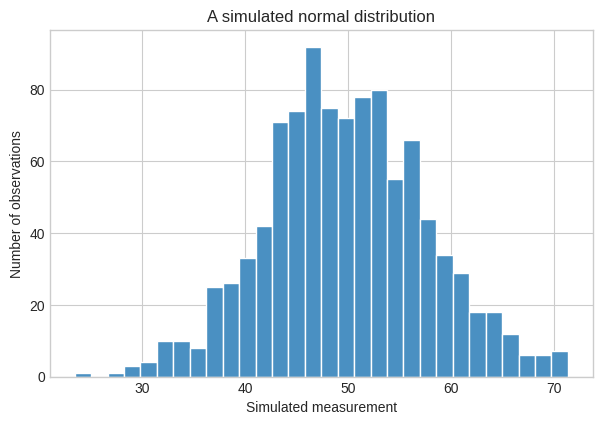

Sample mean: 49.76
Sample standard deviation: 7.84


In [2]:
# Simulate 1,000 measurements centered at 50 with a spread of 8.
normal_sample = rng.normal(loc=50, scale=8, size=1_000)
#rng.normal(...)：生成符合正态分布的随机样本。loc=50：设置总体均值（Mean,mu=50）。scale=8：设置总体标准差（Standard Deviation, sigma=8）。size=1_000：抽样数量为 1,000 个数值。
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(normal_sample, bins=30, color="#4a90c2", edgecolor="white")
ax.set(
    xlabel="Simulated measurement",
    ylabel="Number of observations",
    title="A simulated normal distribution",
)
plt.show()

print(f"Sample mean: {normal_sample.mean():.2f}")#计算样本均值 $\bar{x}$，结果将接近设定值 $50$。
print(f"Sample standard deviation: {normal_sample.std(ddof=1):.2f}")#代表自由度修正（Delta Degrees of Freedom = 1），
#即分母使用 $n-1$ 而非 $n$。在统计学中，使用 $n-1$ 才能对总体的方差/标准差进行无偏估计（Unbiased Estimate）。

### Try it

Draw a normal sample centered at 100 with a standard deviation of 15. How do its histogram and sample summary differ from the one above?

In [3]:
# my_sample = rng.normal(loc=..., scale=..., size=...)
# print(my_sample.mean())
# print(my_sample.std(ddof=1))

### Uniform distribution

In a uniform distribution, every value in an interval is equally likely. A familiar example is an ideal random-number generator that returns any number from 0 to 1. An engineering simulation might choose an initial shaft angle at random between two limits, or sample evenly across an allowable tolerance range.

`rng.uniform(low, high, size)` draws values evenly between two limits. Unlike the normal distribution, it has no single central value that is more likely than another within that interval.

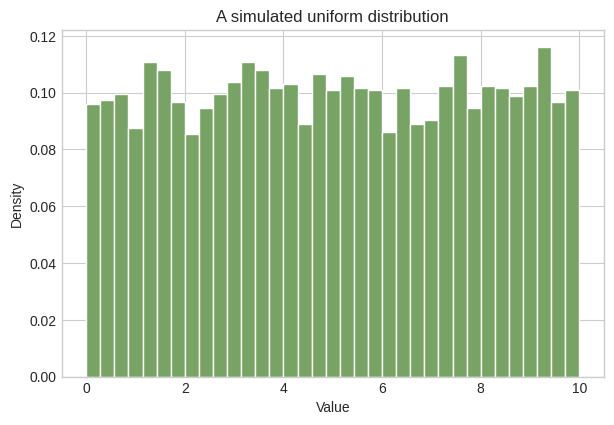

In [4]:
# Draw 5,000 values with equal probability anywhere from 0 to 10.
uniform = rng.uniform(low=0, high=10, size=5_000)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(uniform, bins=35, density=True, color="#77a464", edgecolor="white")
ax.set(title="A simulated uniform distribution", xlabel="Value", ylabel="Density")
plt.show()

### Exponential distribution

An exponential distribution is nonnegative and right-skewed, so it is often used to model waiting times. A familiar example is the waiting time until the next customer arrives when arrivals occur independently at a roughly constant average rate. In engineering, it can model the lifetime of one component when its instantaneous failure rate is assumed constant: a component that has already operated for 10 hours is, under this simplified model, no more or less likely to fail in the next hour than a new one.

`rng.exponential(scale, size)` draws nonnegative, right-skewed values. Its average is approximately `scale`; most draws are relatively small, but occasionally a much larger value occurs.

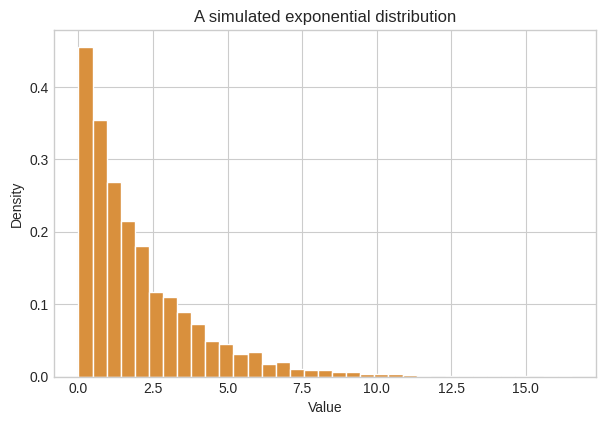

In [5]:
# Draw 5,000 waiting times with an average value of 2.
exponential = rng.exponential(scale=2, size=5_000)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(exponential, bins=35, density=True, color="#d9903d", edgecolor="white")
ax.set(title="A simulated exponential distribution", xlabel="Value", ylabel="Density")
plt.show()

## Check-in

1. Which simulated distribution is symmetric? Which is right-skewed?
2. In `rng.normal(loc, scale, size)`, what does each argument control?
3. Give one setting in which a uniform distribution would be a reasonable model, and one in which it would not.

Keep your answers in your own notes. Bring your questions about these distributions and the CLT to class.

[Return to the Foundations page](index.qmd)